# Curvature

Curvature is where a Finsler manifold stops behaving like a Riemannian one, and the
library separates four objects that the literature often runs together:

| | |
| :--- | :--- |
| `curvature_tensor` | $R^i_{jk}$, the obstruction to integrability of the horizontal distribution |
| `riemannian_curvature` | the Jacobi endomorphism $R_y = R(y,\cdot)$, i.e. $R^i_k = R^i_{jk}y^j$ |
| `ricci_curvature` | its trace, $\mathrm{Ric}(y)$ |
| `flag_curvature` | $\mathbf{K}(P, y)$ — a **flag** and a **flagpole** in it |
| `sectional_curvature` | what the flag curvature degenerates to when the flagpole stops mattering |

Everything is differentiated out of the geodesic spray, so a metric cannot disagree
with its own curvature. The notebook checks that against surfaces whose curvature is
known in closed form, then shows the one thing that has no Riemannian analogue: the
flag curvature depends on *two* directions, not one.

## 1. Setup

Curvature is a third- and fourth-order autodiff chain, so it carries noticeably more
float32 rounding than the rest of the library. Nothing here needs float64 to be
qualitatively right, but the constants come out crisp with it on.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from finslerax.geometry import (
    EuclideanSpace,
    ProjectivelyFlatRanders,
    Randers,
    Riemannian,
    flag_curvature,
    ricci_curvature,
    sectional_curvature,
)
from finslerax.vis.style import PALETTE, use_finslerax_style

use_finslerax_style()
plane = EuclideanSpace(dim=2)

## 2. Surfaces whose curvature we already know

Three Riemannian metrics on the plane, each with a closed form to check against:

* the round sphere in stereographic coordinates, $g = \tfrac{4}{(1+|x|^2)^2} I$, with
  $K = +1$ everywhere;
* the Poincaré half-plane, $g = I/y^2$, with $K = -1$ everywhere;
* the surface of revolution $ds^2 = dx^2 + (1+x^2)\,dy^2$, with
  $K = -1/(1+x^2)^2$ — curvature that actually varies across the domain.

The left column is the computed field over the whole domain; the right column is a
profile through it against the closed form. A constant-curvature panel that came out
constant but with the wrong sign would look fine on its own, which is why the profile
carries the analytic curve rather than a colour bar alone.

In [2]:
def sphere_g(x):
    return (4.0 / (1.0 + jnp.sum(x**2)) ** 2) * jnp.eye(2)


def half_plane_g(x):
    return jnp.eye(2) / x[1] ** 2


def revolution_g(x):
    return jnp.diag(jnp.array([1.0, 1.0 + x[0] ** 2]))


U, V = jnp.array([1.0, 0.0]), jnp.array([0.0, 1.0])


def curvature_field(metric, xs, ys):
    """K over a grid, evaluated once under jit and vmapped over both axes."""
    fn = jax.jit(lambda x: sectional_curvature(metric, x, U, V, check=False))
    grid = jnp.stack(jnp.meshgrid(xs, ys, indexing="ij"), axis=-1)
    return np.asarray(jax.vmap(jax.vmap(fn))(grid))


SURFACES = [
    ("round sphere", Riemannian(plane, sphere_g),
     jnp.linspace(-0.8, 0.8, 33), jnp.linspace(-0.8, 0.8, 33),
     lambda x: np.ones_like(x), "$K = +1$"),
    ("Poincaré half-plane", Riemannian(plane, half_plane_g),
     jnp.linspace(-1.0, 1.0, 33), jnp.linspace(0.4, 2.2, 33),
     lambda x: -np.ones_like(x), "$K = -1$"),
    ("surface of revolution", Riemannian(plane, revolution_g),
     jnp.linspace(-1.6, 1.6, 33), jnp.linspace(-1.0, 1.0, 33),
     lambda x: -1.0 / (1.0 + x**2) ** 2, r"$K = -1/(1+x^2)^2$"),
]

fields = [(name, curvature_field(m, xs, ys), xs, ys, exact, lab)
          for name, m, xs, ys, exact, lab in SURFACES]
print("computed", len(fields), "curvature fields")

computed 3 curvature fields


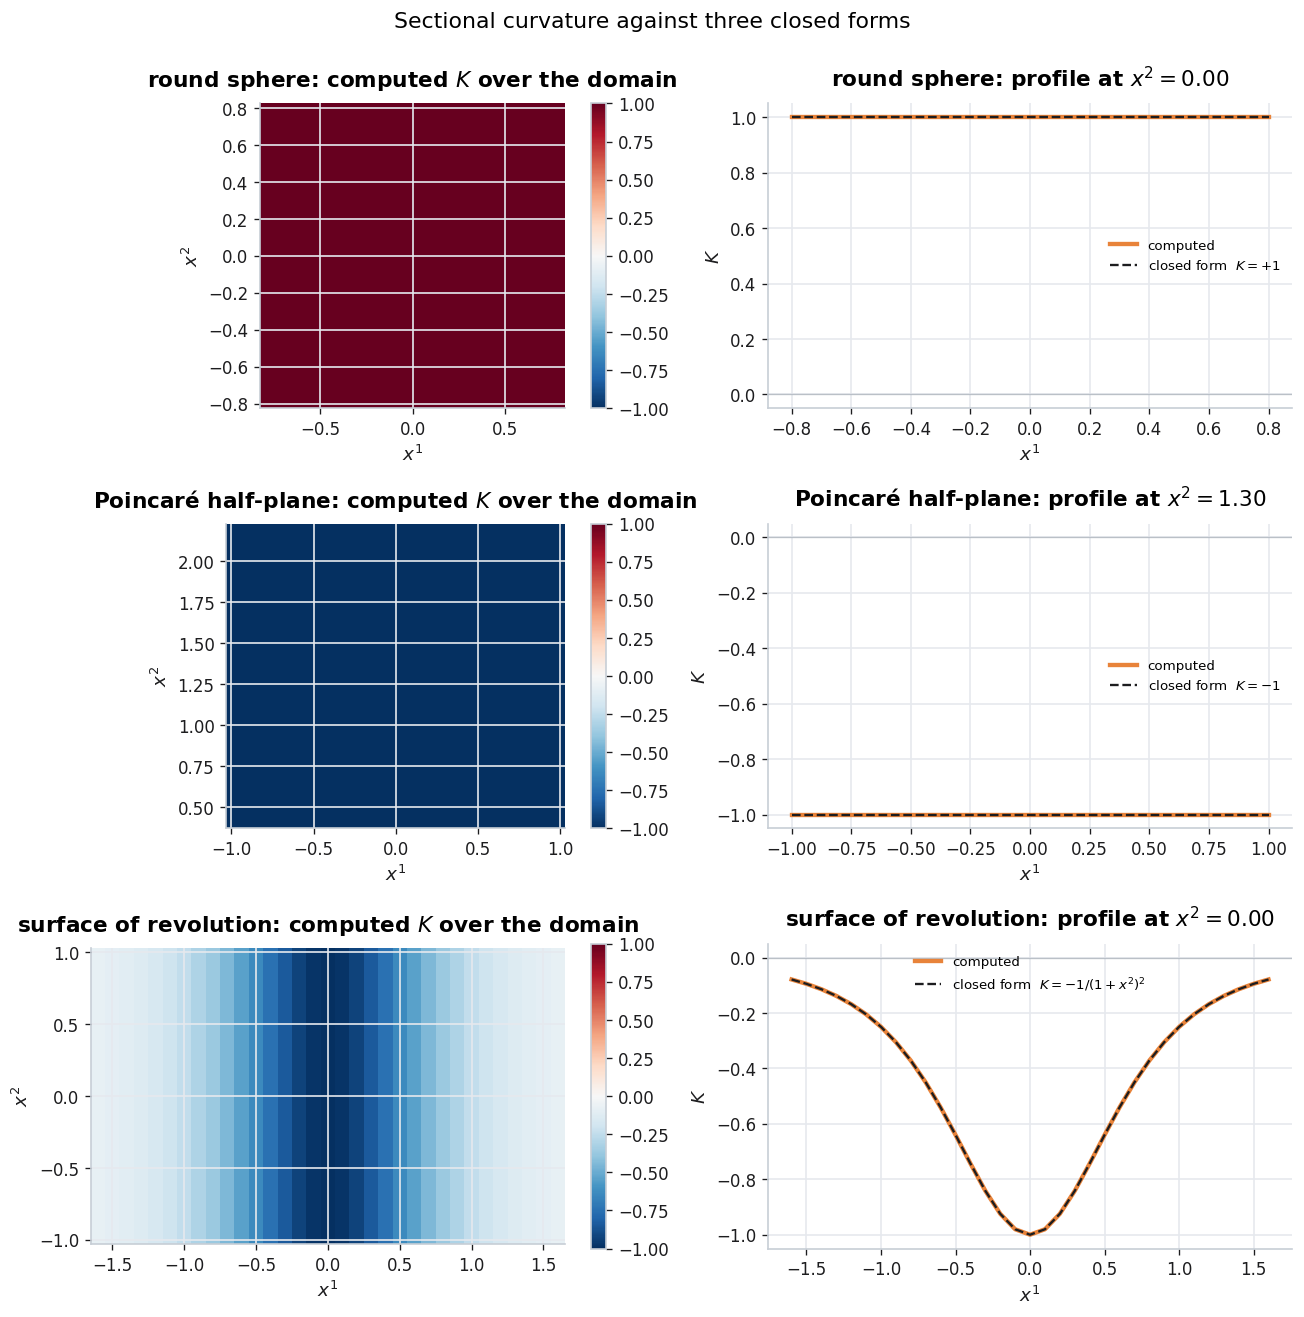

round sphere              max |computed - closed form| = 4.63e-10
Poincaré half-plane       max |computed - closed form| = 4.84e-10
surface of revolution     max |computed - closed form| = 1.00e-10


In [3]:
fig, axes = plt.subplots(3, 2, figsize=(11, 11), gridspec_kw={"width_ratios": [1, 1]})

for row, (name, K, xs, ys, exact, lab) in enumerate(fields):
    ax = axes[row, 0]
    span = max(abs(K.min()), abs(K.max()), 1e-9)
    im = ax.pcolormesh(np.asarray(xs), np.asarray(ys), K.T, cmap="RdBu_r",
                       vmin=-span, vmax=span, shading="nearest")
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f"{name}: computed $K$ over the domain")
    ax.set_xlabel("$x^1$")
    ax.set_ylabel("$x^2$")
    ax.set_aspect("equal")

    # profile along the row nearest the middle of the second axis
    j = len(ys) // 2
    ax = axes[row, 1]
    ax.plot(np.asarray(xs), K[:, j], lw=2.6, color=PALETTE["accent"], label="computed")
    ax.plot(np.asarray(xs), exact(np.asarray(xs)), lw=1.4, ls="--",
            color=PALETTE["ink"], label=f"closed form  {lab}")
    ax.axhline(0.0, color=PALETTE["muted"], lw=0.8, alpha=0.6)
    ax.set_title(f"{name}: profile at $x^2 = {float(ys[j]):.2f}$")
    ax.set_xlabel("$x^1$")
    ax.set_ylabel("$K$")
    ax.legend(fontsize=8)

fig.suptitle("Sectional curvature against three closed forms", y=0.995)
fig.tight_layout()
plt.show()

for name, K, xs, ys, exact, _ in fields:
    ref = exact(np.asarray(xs))[:, None] * np.ones((1, len(ys)))
    print(f"{name:24s}  max |computed - closed form| = {np.abs(K - ref).max():.2e}")

## 3. Why the flag curvature takes two arguments

A Riemannian sectional curvature is a function of a *plane*. Pick two vectors spanning
it and you get the same number either way, because the metric does not know which
direction you asked from.

A Finsler metric does know. The fundamental tensor $g_y$ is itself a function of the
direction, so raising the flag from a different edge of the same plane is a different
measurement. Below, one point, one plane, and the flagpole swept through every
direction in it.

The Riemannian control is flat by construction. The Randers metric is not, and the
spread is not a rounding artefact — it is most of the value.

In [4]:
def sea(x):
    return jnp.array([[1.0 + 0.3 * x[1] ** 2, 0.1 * x[0]], [0.1 * x[0], 1.0]])


def swirl(x):
    return jnp.array([0.35 * jnp.sin(x[1]), 0.25 * jnp.cos(x[0])])


randers = Randers(plane, sea, swirl, wind_mode="raw")
riemann = Riemannian(plane, sea)          # the same sea, wind switched off
x0 = jnp.array([0.2, -0.4])

thetas = jnp.linspace(0.0, 2 * jnp.pi, 240, endpoint=False)


def sweep_flagpole(metric, x):
    """K of one fixed plane, as the flagpole turns through it.

    In 2-D there is only one plane, so the transverse edge can be any vector
    independent of the flagpole; we take the flagpole rotated by 90 degrees.
    """
    def K_at(theta):
        y = jnp.stack([jnp.cos(theta), jnp.sin(theta)])
        u = jnp.stack([-jnp.sin(theta), jnp.cos(theta)])
        return flag_curvature(metric, x, y, u)

    return np.asarray(jax.jit(jax.vmap(K_at))(thetas))


K_randers = sweep_flagpole(randers, x0)
K_riemann = sweep_flagpole(riemann, x0)


def indicatrix(metric, x, n=400):
    """The set F(x, y) = 1, drawn by scaling each direction to unit cost."""
    ang = jnp.linspace(0.0, 2 * jnp.pi, n, endpoint=False)
    dirs = jnp.stack([jnp.cos(ang), jnp.sin(ang)], axis=1)
    costs = jax.vmap(lambda d: metric.metric_fn(x, d))(dirs)
    return np.asarray(dirs / costs[:, None])


print(f"Randers   K spans [{K_randers.min():+.4f}, {K_randers.max():+.4f}]"
      f"   spread {K_randers.max() - K_randers.min():.4f}")
print(f"Riemannian K spans [{K_riemann.min():+.4f}, {K_riemann.max():+.4f}]"
      f"   spread {K_riemann.max() - K_riemann.min():.2e}")

Randers   K spans [-0.6926, +0.0980]   spread 0.7906
Riemannian K spans [-0.2732, -0.2732]   spread 2.74e-12


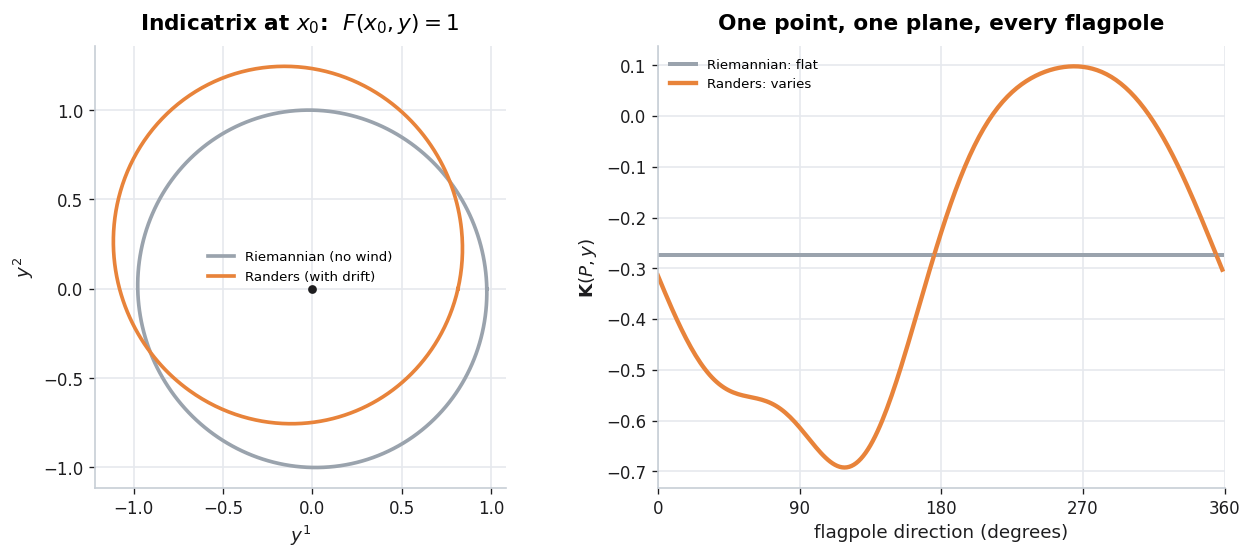

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))

# --- left: the indicatrices, so the asymmetry is visible before the plot of K ---
for metric, col, lab in ((riemann, PALETTE["muted"], "Riemannian (no wind)"),
                         (randers, PALETTE["accent"], "Randers (with drift)")):
    ring = indicatrix(metric, x0)
    ax1.plot(*np.vstack([ring, ring[:1]]).T, lw=2.2, color=col, label=lab)
ax1.scatter([0], [0], s=18, color=PALETTE["ink"], zorder=5)
ax1.set_aspect("equal")
ax1.set_title(r"Indicatrix at $x_0$:  $F(x_0, y) = 1$")
ax1.set_xlabel("$y^1$")
ax1.set_ylabel("$y^2$")
ax1.legend(fontsize=8)

# --- right: K of the one 2-D plane, as the flagpole turns ---
deg = np.degrees(np.asarray(thetas))
ax2.plot(deg, K_riemann, lw=2.4, color=PALETTE["muted"], label="Riemannian: flat")
ax2.plot(deg, K_randers, lw=2.6, color=PALETTE["accent"], label="Randers: varies")
ax2.axhline(K_riemann.mean(), color=PALETTE["muted"], lw=0.9, ls=":")
ax2.set_xlim(0, 360)
ax2.set_xticks([0, 90, 180, 270, 360])
ax2.set_title("One point, one plane, every flagpole")
ax2.set_xlabel("flagpole direction (degrees)")
ax2.set_ylabel(r"$\mathbf{K}(P, y)$")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

The asymmetric indicatrix on the left is the cause of the varying curve on the right.
The Riemannian indicatrix is an ellipse centred on the origin, so opposite directions
are equivalent and $g_y$ is the same for all $y$; the Randers indicatrix is that ellipse
pushed off centre by the drift, and every direction sees a different one.

This is why `flag_curvature` takes the flagpole explicitly, and why asking a Finsler
metric for "the sectional curvature of this plane" is not a well-posed question.

## 4. A metric whose curvature is known and *not* Riemannian

Every check in §2 was Riemannian, and a Riemannian metric cannot catch a sign error
that a compensating convention elsewhere cancels out. `ProjectivelyFlatRanders` closes
that gap: it is Shen's standard model of projectively flat Randers metrics on the unit
ball, whose flag curvature is the constant $-1/4$ — at every point, in every flag, from
every flagpole. With zero drift it is the Funk metric.

Constant flag curvature means constant in *both* arguments, so it should flatten the
§3 sweep as well as the §2 field.

In [6]:
funk = ProjectivelyFlatRanders(plane)                                  # a = 0
drifted = ProjectivelyFlatRanders(plane, a=jnp.array([0.45, 0.0]))     # a != 0

def flag_field(metric, xs, ys, y=U, u=V):
    """K of one fixed flag, over a grid of positions."""
    fn = jax.jit(lambda x: flag_curvature(metric, x, y, u))
    grid = jnp.stack(jnp.meshgrid(xs, ys, indexing="ij"), axis=-1)
    return np.asarray(jax.vmap(jax.vmap(fn))(grid))


r = jnp.linspace(-0.9, 0.9, 41)
K_funk = flag_field(drifted, r, r)

# The metric lives on the open unit ball; the corners of a square grid do not.
# Mask them rather than plotting a number the metric never defined.
gx, gy = np.meshgrid(np.asarray(r), np.asarray(r), indexing="ij")
outside = gx**2 + gy**2 >= 0.9**2
K_funk = np.where(outside, np.nan, K_funk)

K_sweep_funk = sweep_flagpole(funk, jnp.array([0.3, -0.2]))
K_sweep_drift = sweep_flagpole(drifted, jnp.array([0.3, -0.2]))

print(f"field  ({np.isfinite(K_funk).sum()} points inside the ball)"
      f"   max |K + 1/4| = {np.nanmax(np.abs(K_funk + 0.25)):.2e}")
print(f"sweep   max |K + 1/4| = {np.abs(K_sweep_drift + 0.25).max():.2e}")

field  (1245 points inside the ball)   max |K + 1/4| = 4.53e-10
sweep   max |K + 1/4| = 3.56e-09


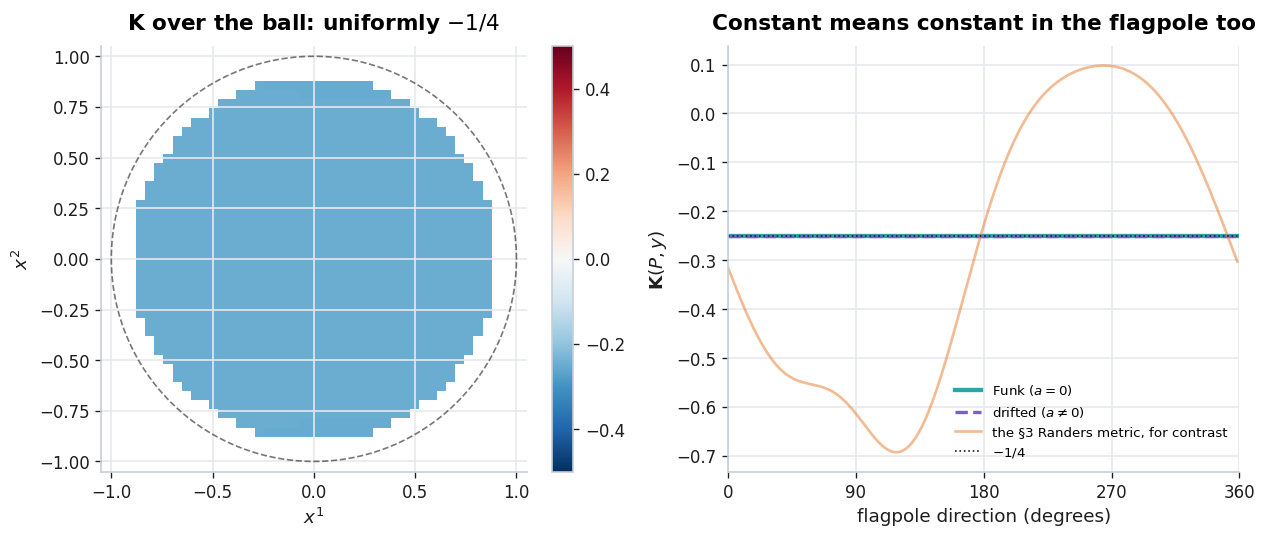

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))

im = ax1.pcolormesh(np.asarray(r), np.asarray(r), K_funk.T, cmap="RdBu_r",
                    vmin=-0.5, vmax=0.5, shading="nearest")
fig.colorbar(im, ax=ax1, fraction=0.046)
bd = np.linspace(0, 2 * np.pi, 400)
ax1.plot(np.cos(bd), np.sin(bd), color=PALETTE["ink"], lw=1.0, ls="--", alpha=0.6)
ax1.set_xlim(-1.05, 1.05)
ax1.set_ylim(-1.05, 1.05)
ax1.set_aspect("equal")
ax1.set_title(r"$\mathbf{K}$ over the ball: uniformly $-1/4$")
ax1.set_xlabel("$x^1$")
ax1.set_ylabel("$x^2$")

deg = np.degrees(np.asarray(thetas))
ax2.plot(deg, K_sweep_funk, lw=2.6, color=PALETTE["teal"], label="Funk ($a = 0$)")
ax2.plot(deg, K_sweep_drift, lw=2.0, ls="--", color=PALETTE["violet"],
         label=r"drifted ($a \neq 0$)")
ax2.plot(deg, K_randers, lw=1.6, color=PALETTE["accent"], alpha=0.55,
         label="the §3 Randers metric, for contrast")
ax2.axhline(-0.25, color=PALETTE["ink"], lw=1.0, ls=":", label=r"$-1/4$")
ax2.set_xlim(0, 360)
ax2.set_xticks([0, 90, 180, 270, 360])
ax2.set_title("Constant means constant in the flagpole too")
ax2.set_xlabel("flagpole direction (degrees)")
ax2.set_ylabel(r"$\mathbf{K}(P, y)$")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

Both of these metrics are genuinely non-reversible — $F(x, y) \neq F(x, -y)$ — and both
sit flat on $-1/4$. That is a much sharper test of the index and sign convention than any
Riemannian surface can provide, and it is what the test suite asserts.

The Ricci curvature gives an independent check of the same constant, through
$\mathrm{Ric}(y) = (n-1)\,\lambda\, F^2(x, y)$:

In [8]:
pts = [jnp.array(p) for p in ([0.0, 0.0], [0.3, -0.2], [-0.45, 0.35], [0.1, 0.6])]
dirs = [jnp.array(d) for d in ([1.0, 0.3], [-0.6, 0.9], [0.2, 1.0])]

print(f"{'x':>18}  {'y':>14}  {'Ric(y)':>10}  {'(n-1) K F^2':>12}")
for x in pts:
    for y in dirs:
        ric = float(ricci_curvature(drifted, x, y))
        pred = (2 - 1) * (-0.25) * float(2.0 * drifted.energy(x, y))
        print(f"{str(np.asarray(x)):>18}  {str(np.asarray(y)):>14}  "
              f"{ric:>10.6f}  {pred:>12.6f}")

                 x               y      Ric(y)   (n-1) K F^2


           [0. 0.]       [1.  0.3]   -0.558032     -0.558032


           [0. 0.]     [-0.6  0.9]   -0.164700     -0.164700


           [0. 0.]       [0.2 1. ]   -0.307916     -0.307916


       [ 0.3 -0.2]       [1.  0.3]   -0.832792     -0.832792


...

     [-0.45  0.35]     [-0.6  0.9]   -1.107041     -1.107041


     [-0.45  0.35]       [0.2 1. ]   -0.807927     -0.807927


         [0.1 0.6]       [1.  0.3]   -1.280834     -1.280834


         [0.1 0.6]     [-0.6  0.9]   -1.065877     -1.065877


         [0.1 0.6]       [0.2 1. ]   -1.807245     -1.807245


## 5. `sectional_curvature` degenerates on its own

`sectional_curvature` is the Riemannian quantity, and it is only defined where the
flagpole does not matter. Rather than trusting the caller, it checks: a metric that
declares itself Riemannian takes the direct path, and anything else is verified by
evaluating the same plane from both edges.

So the two cells below are the intended behaviour, not a limitation — a Finsler metric
has no single sectional curvature to return, and §3 is the reason.

In [9]:
print("Riemannian metrics answer directly")
for name, metric in (("sphere", Riemannian(plane, sphere_g)),
                     ("sea, wind off", Randers(plane, sea, swirl, use_wind=False))):
    K = sectional_curvature(metric, jnp.array([0.2, 0.1]), U, V)
    print(f"  {name:16s} is_riemannian={metric.is_riemannian!s:5s}  K = {float(K):+.6f}")

print("\nA genuinely Finslerian metric refuses")
try:
    sectional_curvature(randers, x0, U, V)
except Exception as exc:
    message = next(line.strip() for line in str(exc).splitlines()
                   if "sectional_curvature is defined" in line)
    print(f"  {type(exc).__name__}")
    for chunk in (message[:78], message[78:156], message[156:]):
        if chunk:
            print(f"    {chunk}")

print("\nAsk for the flag curvature instead, with the flagpole named")
for y in (U, V):
    K = flag_curvature(randers, x0, y, jnp.array([-y[1], y[0]]))
    print(f"  flagpole {np.asarray(y)}  ->  K = {float(K):+.6f}")

Riemannian metrics answer directly


  sphere           is_riemannian=True   K = +1.000000


  sea, wind off    is_riemannian=True   K = -0.298327

A genuinely Finslerian metric refuses


  EquinoxRuntimeError
    equinox.EquinoxRuntimeError: sectional_curvature is defined only for Riemannia
    n metrics: the flag curvature of this plane depends on the flagpole. Use flag_
    curvature(metric, x, y, u), which takes the flagpole explicitly.

Ask for the flag curvature instead, with the flagpole named


  flagpole [1. 0.]  ->  K = -0.314098


  flagpole [0. 1.]  ->  K = -0.613426


## 6. Takeaways

* Curvature is differentiated from the spray, so it agrees with the metric by
  construction. It reproduces $K = +1$ on the sphere, $-1$ on the hyperbolic plane and
  $-1/(1+x^2)^2$ on the surface of revolution, with no closed form written down.
* `flag_curvature(metric, x, y, u)` takes the flagpole explicitly because the answer
  depends on it. That dependence is the Finslerian content, not an inconvenience.
* `sectional_curvature` is the Riemannian degeneration and says so, refusing the metrics
  where it would have to pick one number out of many.
* `ProjectivelyFlatRanders` is a non-Riemannian metric with a known constant flag
  curvature of $-1/4$, which makes it the sharpest available check on the sign and index
  conventions of the whole pipeline.
* Curvature is third- and fourth-order autodiff. Compile once with `jax.jit` and reuse;
  it is analysis machinery rather than something to put in a training loop.